# 2. Assignment - Medical Image Processing and Machine Learning

### VU 193.215 - 2026 Summer Term

**Due**: 20.06.2026, 23:59 (CET) - one submission per team via TUWEL

**Mandatory group interviews**: 25.06.2026 - 09:00 - 13:25 (CET)  (20 min slots)

### Structure 
Before submitting, ensure you have followed these formatting requirements:
- **This notebook:** Contains code only (no theory/text answers). Please also rename the `notebook.ipynb` to `notebook_XX.ipynb`, where `XX` holds your group number.
- **PDF-Report:** Contains all theoretical answers **from the exercise sheet** (not included in this notebook) and data interpretations. Please add the corresponding (sub-) task number for each interpretation/answer in the PDF report.

---

### Assignment

Aim of the second assignment is the implementation of a segmentation algorithm for bone contours. We will investigate image features extraction and selection methods as bases for image segmentation. Three different approaches are investigated, (1) a classifier based approach using Random Forests, (2) a Deep Learning approach using a UNet and (3) a bone contour Shape Model based approach that uses PCA resulting in a simplified version of Particle Filters.

Relevant topics within this exercise:
- Feature extraction
- Classification and feature selection using Random Forests
- Implementation and optimization of a cost function for segmentation


#### Helper Functions in `helper_functions.py`

- `get_data` loads all the necessary variables that you will be working on
- `plot_shape` can be used to plot generated shapes and the given mean shape
- `plot_convolutions` plots images along with their convolutions
- `plot_prediction_triplets` plots triplets of images, segmentation predictions and segmentation ground truths
- `show_feature_importance` visualizes the importance of a Random Forest's features
- `evaluate_binary_segmentation` evaluates a binary segmentation using a Confusion Matrix, Dice Score, Precision and Recall
- `optimize` is used to optimize parameters with a given cost function `f`
- `plot_fitted_shapes` plots fitted shapes together with a segmentation and optionally with the ground truth landmarks

`train_unet_model` trains a U-Net and returns the trained model and is contained in `training.py`

### Information

Please update the following information.

**Group number:** 12

**Group members:** 
- Marlene Bauer
- Iana Bembeeva
- Julia CHalissery
- Dzhamilia Kulikieva

In [1]:
# h5py is installed through setup/environment.yml in the boneseg-env environment.


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from helper_functions import get_data


### Load data used in this exercise

In [3]:
images, masks, landmarks, aligned = get_data()


images: list of 50 images, each as a 2D array with varying sizes
masks: list of 50 contour segmentation masks, each as a 2D array with varying sizes - corresponding to images
landmarks: list of 50 raw landmark coordinates, each as a 2D array of shape (2, n_landmarks)
aligned: np.ndarray of shape (50, 2, 64) containing aligned landmark coordinates for all samples, preprocessed for PCA


# 1. Data Exploration

### 1.1. Plot the first 5 bone images (stored in `images`) and the respective landmarks (stored in `landmarks`) on top.
- Hint: `imshow` and `scatter`

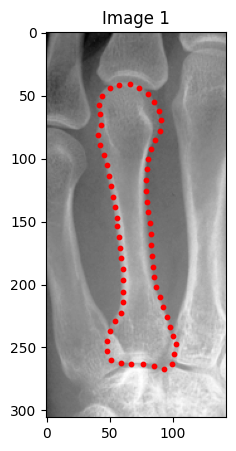

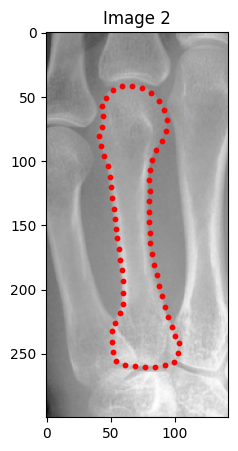

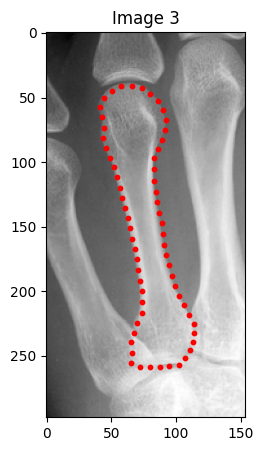

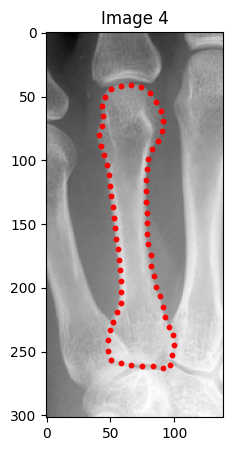

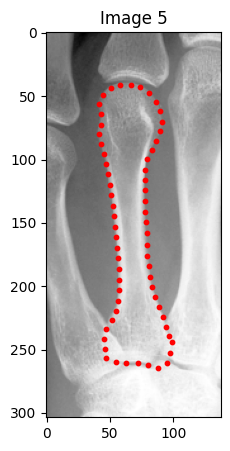

In [4]:
# Plot the first 5 bone images
for i in range(5):
    plt.figure(figsize=(5,5))
    plt.imshow(images[i],cmap="gray")
    plt.scatter(
        landmarks[i][0,:], #x-Koordinaten
        landmarks[i][1,:],#y-Koordinaten
        c="r", s=10
    )
    plt.title(f"Image {i+ 1}")
    plt.show()


### 1.2. Plot one set of landmarks together with the corresponding set of aligned landmarks.

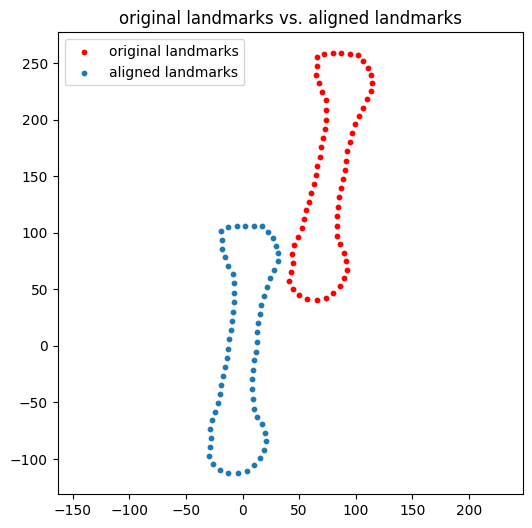

In [5]:
# Plot one set of landmarks together with the corresponding set of aligned landmarks

i=2
plt.figure(figsize=(6,6))
plt.scatter(
    landmarks[i][0,:], #x-koordinaten
    landmarks[i][1,:], #y-koordinaten
    label="original landmarks",
    c="r",s=10
)
plt.scatter(
    aligned[i][0,:],
    aligned[i][1,:],
    label="aligned landmarks",
    s=10
)
plt.axis("equal")
plt.title("original landmarks vs. aligned landmarks")
plt.legend()
plt.show()


### 1.3. Extend `generate_shape` so that it allows rotation, scaling and translation of shapes according to the parameters `scaling, rotation, x_t, y_t` and test your function.

- Copy your function `generate_shape` from Assignment 1.
- Add functionality for rotation, scaling and translation (hint: rotation matrix).


In [6]:

def generate_shape(b, eigen_vectors, mean_shape, scaling, rotation, x_t, y_t):
    """Generate a PCA shape and apply scale, rotation, and translation."""
    b = np.asarray(b)
    selected_eigVec = eigen_vectors[:, :len(b)]
    new_shape_flat = mean_shape + np.dot(selected_eigVec, b)

    n_points = new_shape_flat.shape[0] // 2
    shape_points = np.stack([
        new_shape_flat[:n_points],
        new_shape_flat[n_points:]
    ], axis=1)
    shape_points *= scaling

    angle = np.deg2rad(rotation)
    rotation_matrix = np.array([
        [np.cos(angle), -np.sin(angle)],
        [np.sin(angle),  np.cos(angle)]
    ])

    shape_points = shape_points @ rotation_matrix.T
    shape_points[:, 0] += x_t
    shape_points[:, 1] += y_t

    return np.hstack([shape_points[:, 0], shape_points[:, 1]])


### 1.4. Test your adapted function `generate_shape`.

- Perform PCA on the first 30 landmark sets in `aligned` with a reasonable number of components (required data shape: (30, 128)). You may use the function `PCA` from `sklearn`.
- Use your group number assigned in TUWEL for parameterizing the following transformations:
    - rotate by **90 + 2 * 12 degrees**
    - translate by **90 + 12 pixels** in x direction and **-50 pixels** in y direction
    - scale by a factor of **1.5**
    - use a PCA weight vector of your choice
- Apply the transformation and plot the shape and the mean_shape using `plot_shape`

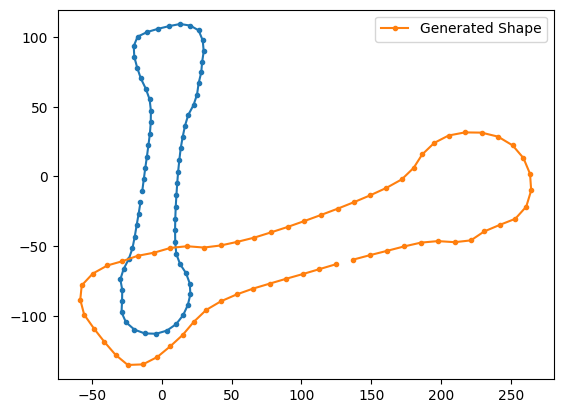

In [7]:
from helper_functions import plot_shape
from sklearn.decomposition import PCA

data = np.stack([lm.flatten() for lm in aligned[:30]])  # shape (30,128)

n_comp = 5 # chosen number of components

# Perform PCA on the data and get the eigen vectors, eigen values, and mean shape
pca =PCA(n_components=n_comp)
pca.fit(data)
eigen_vectors=pca.components_.T
eigen_values =pca.explained_variance_
mean_shape=pca.mean_
#print(eigen_vectors, eigen_values, mean_shape)

# PCA weight vector (zeros uses mean shape)
b = np.zeros(n_comp)# choose PCA weights
b[0]=0.5
b[1]=-0.5
# Affine transform parameters for testing
scaling = 1.5 # set scaling
rotation =90+2*12 # set rotation
x_t, y_t =90+12,-50 # set x and y translation

# Generate the shape
new_shape =generate_shape(b,eigen_vectors,mean_shape,scaling,rotation,x_t,y_t) 

# Plot the generated and mean shapes
plot_shape(new_shape, mean_shape)


# 2. Feature Extraction and Edge Detection via Convolutions

### 2.1. Edge Detection via Convolutions
#### (a) Kernels
Create 2 edge detection kernels (image filters) represented as matrices (Fx, Fy) of dimension `[i,j]` where `i` and `j` are 3. We will focus on the filters called Prewitt Operator. These have the aim to identify edges in images by focusing on detecting changes in intensity levels. You should implement a horizontal and vertical edge detection filter. You may also create additional kernels for edge detection, if you want to experiment with these.


In [8]:

# Define PREWITT kernels for X and Y
import numpy as np

Fx = np.array([
    [ 1,  0, -1],
    [ 1,  0, -1],
    [ 1,  0, -1]
], dtype=float)

Fy = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1]
], dtype=float)

PREWITT_X = Fx
PREWITT_Y = Fy

print("Fx:")
print(Fx)
print("Fy:")
print(Fy)


Fx:
[[ 1.  0. -1.]
 [ 1.  0. -1.]
 [ 1.  0. -1.]]
Fy:
[[-1. -1. -1.]
 [ 0.  0.  0.]
 [ 1.  1.  1.]]


#### (b) Convolution operation
- Implement the convolution operation on your own as function `conv2d` with input parameters `image` representing a 2D image of size [m, n] and `kernel` representing a `3x3` filter kernel.
- The output should be the convolved image of size [m,n]. For convolving the kerning at the image boundaries image padding with 0 values should be used.

In [9]:

def conv2d(image, kernel):
    """Convolve a 2D image with a 3x3 kernel and keep the input size."""
    output = np.zeros_like(image, dtype=float)
    padded_image = np.pad(image, pad_width=1, mode='constant', constant_values=0)
    kernel_flipped = np.flip(kernel)

    height, width = image.shape
    for m in range(height):
        for n in range(width):
            roi = padded_image[m:m + 3, n:n + 3]
            output[m, n] = np.sum(roi * kernel_flipped)

    return output


#### (c) Test your convolution operation
- Select 3 random bone images from `images` and convolve each of them with the filters you created.
- Visualize the resulting images using `plot_convolutions`.

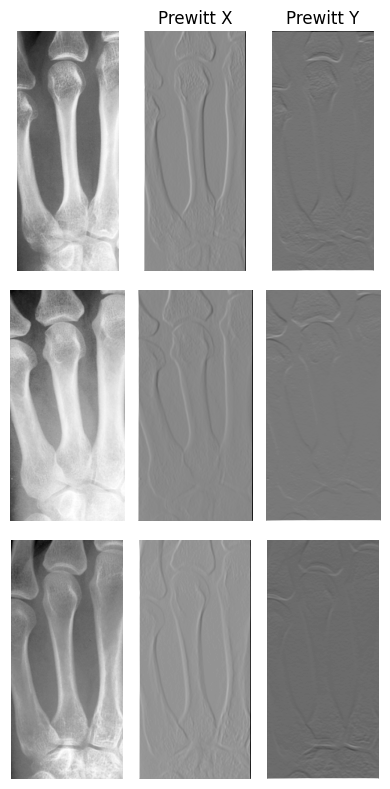

In [10]:

import random
from helper_functions import plot_convolutions

kernels = {
    'Prewitt X': PREWITT_X,
    'Prewitt Y': PREWITT_Y,
}

originals = random.sample(list(images), 3)
convolved = []
for image in originals:
    conv = [conv2d(image, kernel) for kernel in kernels.values()]
    convolved.append(conv)

plot_convolutions(originals, convolved, kernels)


### 2.2. Image Feature Computation
- Implement `compute_features(image)` which returns a feature matrix of size `[nfeatures, npixels]` of an image, including the following features:
    - Grey value of an image
    - Gradient in x- and y-direction (using the kernels you created)
    - Magnitude of the gradient
    - x- and y-coordinates of the pixels (hint: `np.meshgrid`)
- Feel free to implement and evaluate other additional features. You are free to use libraries such as `skimage` (e.g. from [features](https://scikit-image.org/docs/0.25.x/api/skimage.feature.html) or [filters](https://scikit-image.org/docs/0.25.x/api/skimage.filters.html)).
- Visualize the features for the first image in `images`.

Note: some features may be computationally expensive, so the results of `compute_features` can be cached. If you wish to not use this feature, you can remove the annotation (`@memory.cache`). In case you change your implementation of `compute_features`, do not forget to delete the directory `cache_dir` to clear the cache.

In [11]:
# scikit-image is installed through setup/environment.yml in the boneseg-env environment.


In [12]:
from joblib import Memory
cache_dir = os.path.join(os.getcwd(), 'cache_dir')
memory = Memory(location=cache_dir, verbose=0)


In [13]:

from skimage.feature import canny

@memory.cache
def compute_features(image):
    """Return image features as an array with shape (n_features, n_pixels)."""
    H, W = image.shape

    grey = image.flatten()
    edge_x = conv2d(image, PREWITT_X).flatten()
    edge_y = conv2d(image, PREWITT_Y).flatten()
    gradient_magnitude = np.sqrt(edge_x**2 + edge_y**2)
    canny_edges = canny(image, sigma=1.0).flatten()

    y_grid, x_grid = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')
    x_coords = x_grid.flatten()
    y_coords = y_grid.flatten()

    return np.vstack([
        grey,
        edge_x,
        edge_y,
        gradient_magnitude,
        canny_edges,
        x_coords,
        y_coords,
    ])

# Alias for the function name used in some versions of the assignment sheet.
computeFeatures = compute_features


#### Visualize Features

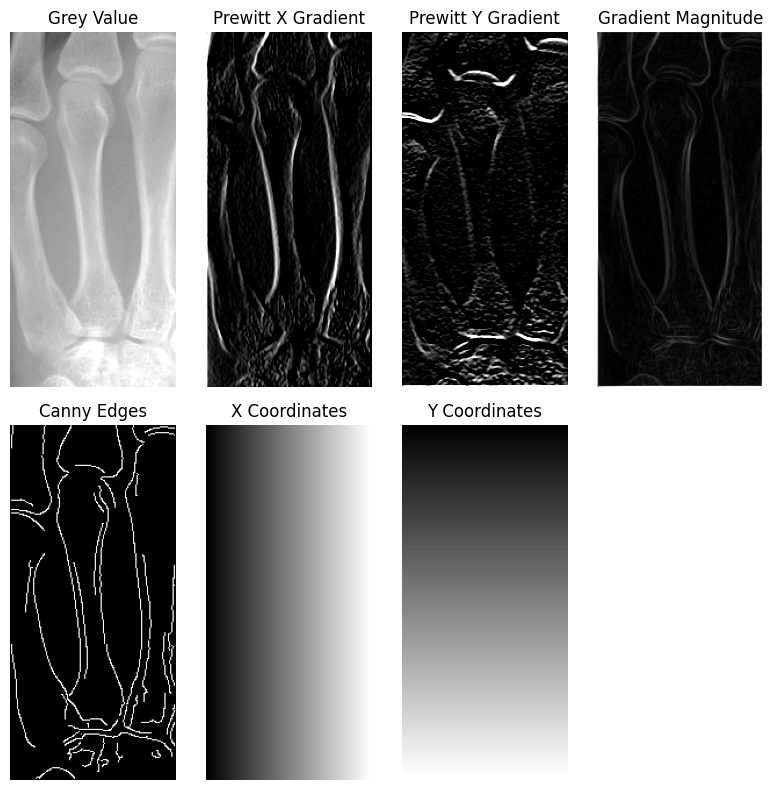

In [14]:
test_image = images[0]
H, W = test_image.shape
features_test = compute_features(test_image)

# Get titles and features for plotting
titles = [
    "Grey Value", 
    "Prewitt X Gradient", 
    "Prewitt Y Gradient", 
    "Gradient Magnitude", 
    "Canny Edges", 
    "X Coordinates", 
    "Y Coordinates"
]
feats = [features_test[i].reshape(H, W) for i in range(features_test.shape[0])]

fig, axes = plt.subplots(2,4, figsize=(8, 8))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    if idx < len(feats):
        ax.imshow(feats[idx], cmap='gray', vmin=0, vmax=np.percentile(feats[idx], 99))
        ax.set_title(titles[idx])
    ax.axis('off')

plt.tight_layout()
plt.show()


# 3. Classification and Feature Selection
In this task we investigate how image features are selected to train a classifier to solve a binary classification task - the detection of edges (bone contours) in an image.

The classification result provides per image pixel a label, where 1 denotes an edge  and 0 background/no edge. In total in this tasks we will compare and explore three bone contour extraction methods: (1) Random Forest, (2) a U-Net based Deep Learning framework and (3) Particle Filters using a defined training and testing set.


### 3.1. Data Preparation
- Split the image set of 50 images and the corresponding masks into a training set of 30 images (`I_train`) and masks (`y_train`) and a test set of 20 images (`I_test`) and corresponding masks (`y_test`).
- Compute the features of all images and store them in `X_train` and `X_test`, respectively.

In [15]:
I_train = images[:30]
y_train = masks[:30]

I_test = images[30:50]
y_test = masks[30:50]


In [16]:
print("Number of train images:", len(I_train))
print("Number of train masks:", len(y_train))
print("Number of test images:", len(I_test))
print("Number of test masks:", len(y_test))

print("Type of one image:", type(I_train[0]))
print("Shape of one image:", I_train[0].shape)
print("Shape of one mask:", y_train[0].shape)


Number of train images: 30
Number of train masks: 30
Number of test images: 20
Number of test masks: 20
Type of one image: <class 'numpy.ndarray'>
Shape of one image: (306, 143)
Shape of one mask: (306, 143)


### 3.2. Random Forest (RF)
- Implement the function `train_rf` which takes a list of feature arrays and labels (masks) and trains a Random Forest classifier and returns the trained classifier.
- Implement the function `predict_segmentation_rf` which takes a trained Random Forest classifier and an image and returns a predicted segmentation.

#### (a) Define a Random Forest Classifier
- Use the `RandomForestClassifier` from `sklearn`.
- Get familiar with the parameters and select suitable ones for training.
- The RF classifier should be trained on **extracted image features** and not the images directly. Thus, compute image features for all input images in `I_train` and `I_test` and store the resulting features in `X_train` and `X_test`.
- **Hint**: to speed up the training process you should use all pixels of the bone contours but only a randomly sampled subset of the background pixels (equal amount of fore- (bone contours) and background (non-bone contours)).

In [17]:
X_train = [compute_features(image) for image in I_train]
X_test = [compute_features(image) for image in I_test]


In [18]:
from sklearn.ensemble import RandomForestClassifier


In [19]:

def train_rf(features, labels, n_trees=100, random_state=0):
    """Train a Random Forest on balanced contour/background pixels."""
    X = np.hstack(features).T
    y = np.concatenate([mask.flatten() for mask in labels])
    y = (y > 0).astype(np.uint8)

    positive_idx = np.where(y == 1)[0]
    negative_idx = np.where(y == 0)[0]

    rng = np.random.default_rng(random_state)
    negative_sample_idx = rng.choice(
        negative_idx,
        size=len(positive_idx),
        replace=False,
    )

    selected_idx = np.concatenate([positive_idx, negative_sample_idx])
    rng.shuffle(selected_idx)

    clf = RandomForestClassifier(
        n_estimators=n_trees,
        random_state=random_state,
        n_jobs=-1,
        oob_score=True,
    )
    clf.fit(X[selected_idx], y[selected_idx])

    return clf


#### (b) Train the classifier
- Use the image features  `X_train` as input to train a Random Forest classifier and the corresponding image masks `y_train` as class labels.

In [20]:
rf_classifier = train_rf(X_train, y_train)


In [21]:
print(rf_classifier)


RandomForestClassifier(n_jobs=-1, oob_score=True, random_state=0)


#### (c) Predict segmentations
- Implement the function `predict_segmentation_rf` which takes the Random Forest classifier as well as an image and returns the prediction from the classifier.
- Visualize the prediction of the first test image (from `I_test`) and compare it to the corresponding target label from `y_test`.

In [22]:

def predict_segmentation_rf(clf, image):
    """Predict a binary segmentation mask for one image using the RF classifier."""
    H, W = image.shape
    features = compute_features(image).T
    prediction = clf.predict(features)
    return prediction.reshape(H, W)


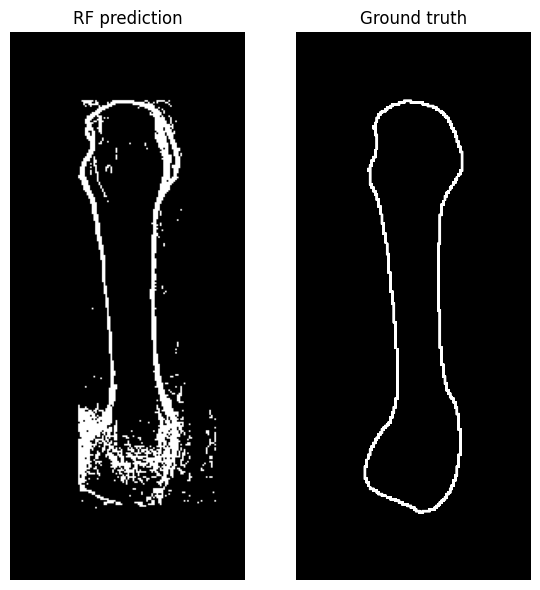

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 6))

# Visualize the predicted segmentation and the ground truth mask

pred_seg = predict_segmentation_rf(rf_classifier, I_test[0])


ax1.imshow(pred_seg, cmap="gray", vmin=0, vmax=1)
ax1.set_title("RF prediction")
ax1.axis("off")

ax2.imshow(y_test[0], cmap="gray", vmin=0, vmax=1)
ax2.set_title("Ground truth")
ax2.axis("off")

plt.tight_layout()
plt.show()


#### (d) Predict all bone contours
- Use the trained classifier and predict bone contours for the feature test set `X_test` and store the predictions in `y_pred_RF`.
- Compare the bone contour predictions to the target labels `y_test` using the helper function `evaluate_binary_segmentation` to get Dice Score, Precision and Recall.

In [24]:
y_pred_RF = [predict_segmentation_rf(rf_classifier, image) for image in I_test]


In [25]:
print("Number of RF predictions:", len(y_pred_RF))
print("First prediction shape:", y_pred_RF[0].shape)
print("First ground truth shape:", y_test[0].shape)
print("Unique values in first prediction:", np.unique(y_pred_RF[0]))


Number of RF predictions: 20
First prediction shape: (322, 138)
First ground truth shape: (322, 138)
Unique values in first prediction: [0 1]


In [26]:
from helper_functions import plot_prediction_triplets, show_feature_importance, evaluate_binary_segmentation


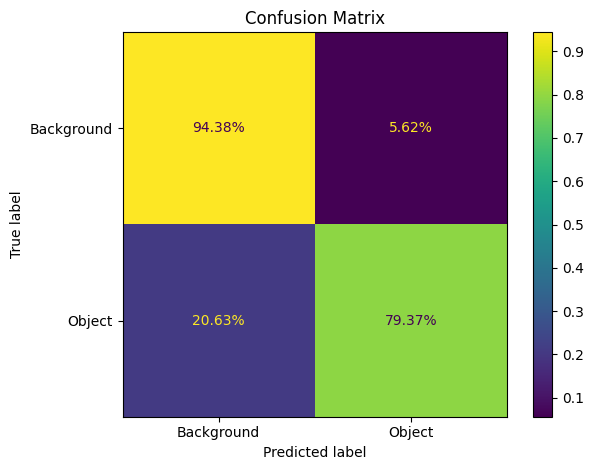

Dice Score: 0.25824554371108965
Precision: 0.1542098019268745
Recall: 0.7937167937167937


In [27]:
results = evaluate_binary_segmentation(y_pred_RF, y_test)
print("Dice Score:", results['dice'])
print("Precision:", results['precision'])
print("Recall:", results['recall'])


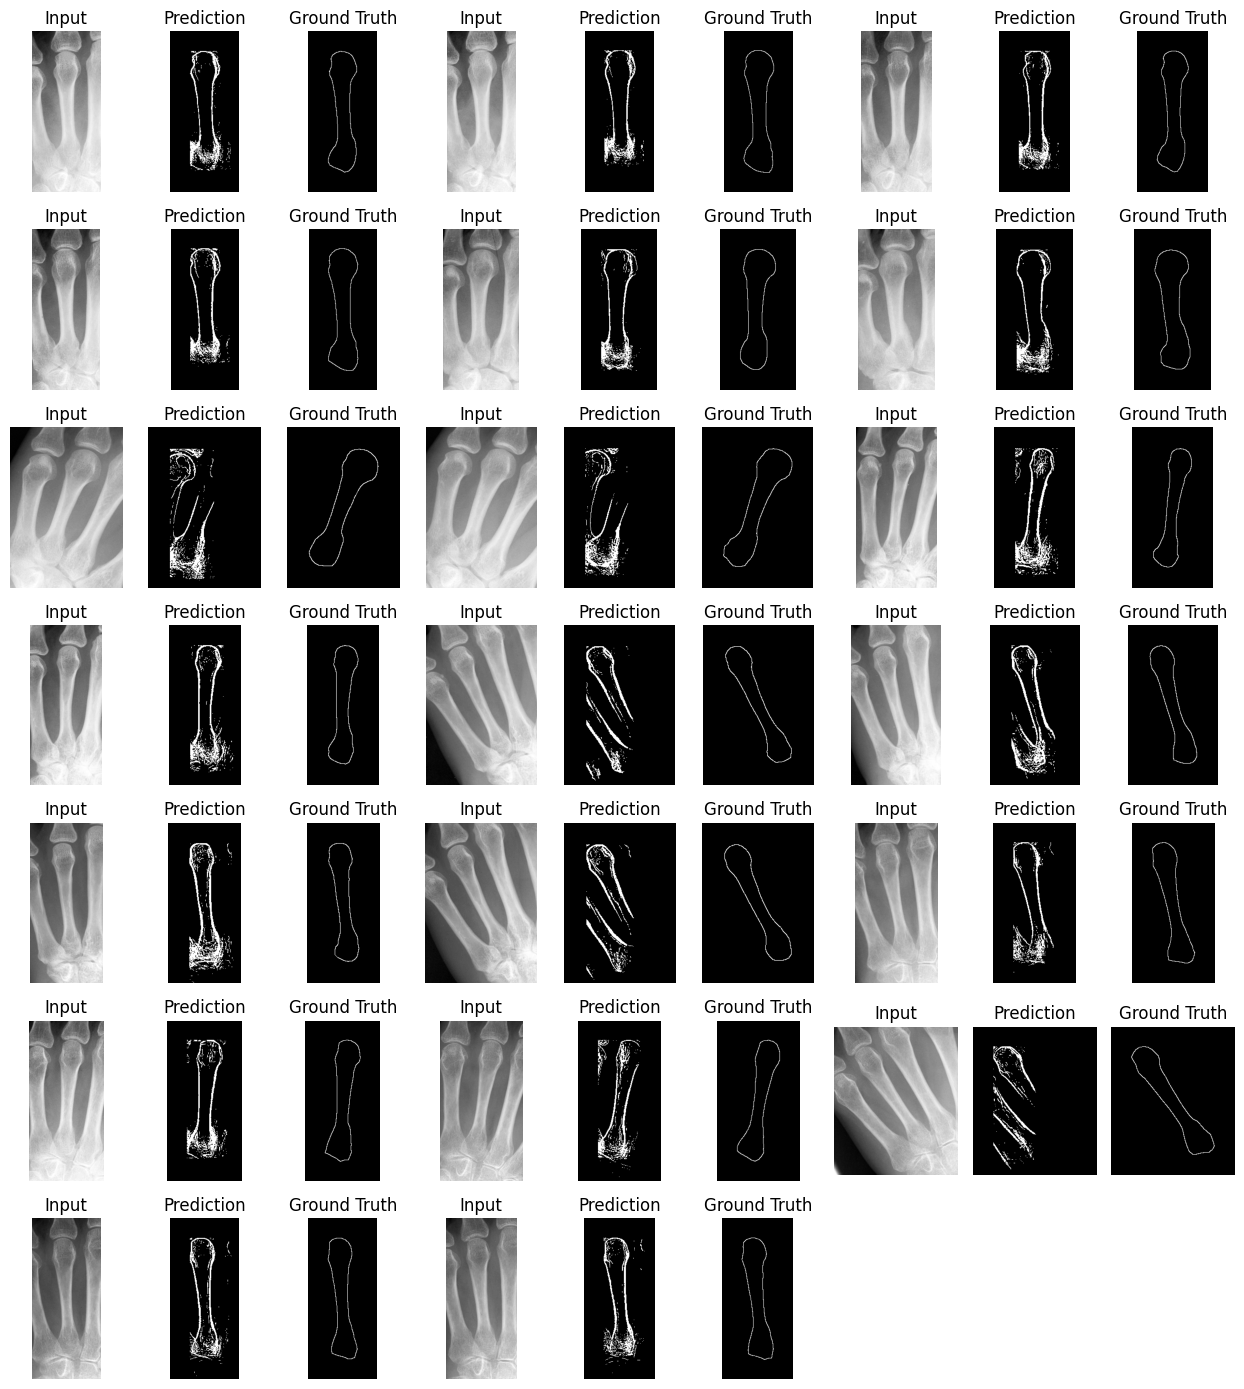

In [28]:
plot_prediction_triplets(I_test, y_pred_RF, y_test)


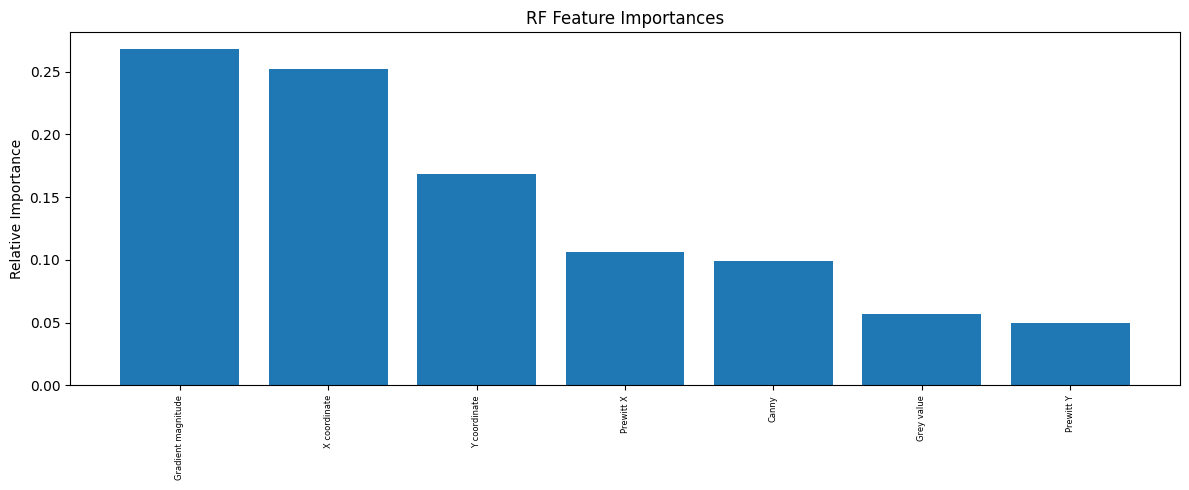

In [29]:
titles = [
    "Grey value",
    "Prewitt X",
    "Prewitt Y",
    "Gradient magnitude",
    "Canny",
    "X coordinate",
    "Y coordinate"
]

show_feature_importance(rf_classifier, titles)


In [30]:
feature_titles = [
    "Grey value",
    "Prewitt X",
    "Prewitt Y",
    "Gradient magnitude",
    "Canny",
    "X coordinate",
    "Y coordinate"
]


In [31]:
def select_features(feature_list, feature_indices):
    """
    Select a subset of features from a list of feature matrices.

    Each feature matrix has shape (F, N), where F is the number of features
    and N is the number of pixels.
    """
    return [features[feature_indices, :] for features in feature_list]


In [32]:
def predict_segmentation_rf_selected(clf, image, feature_indices):
    """
    Predict a binary segmentation mask using only selected features.
    """
    H, W = image.shape

    features = compute_features(image)
    features = features[feature_indices, :]
    features = features.T

    prediction = clf.predict(features)
    prediction_mask = prediction.reshape(H, W)

    return prediction_mask


In [33]:
feature_sets = {
    "All features": [0, 1, 2, 3, 4, 5, 6],
    "Without coordinates": [0, 1, 2, 3, 4],
    "Without Canny": [0, 1, 2, 3, 5, 6],
    "Only gradients": [1, 2, 3],
    "Only grey + gradients": [0, 1, 2, 3],
}


Training: All features


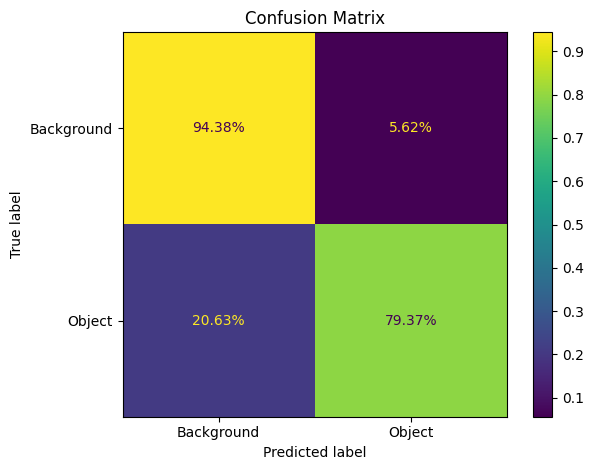

Dice: 0.25824554371108965
Precision: 0.1542098019268745
Recall: 0.7937167937167937

Training: Without coordinates


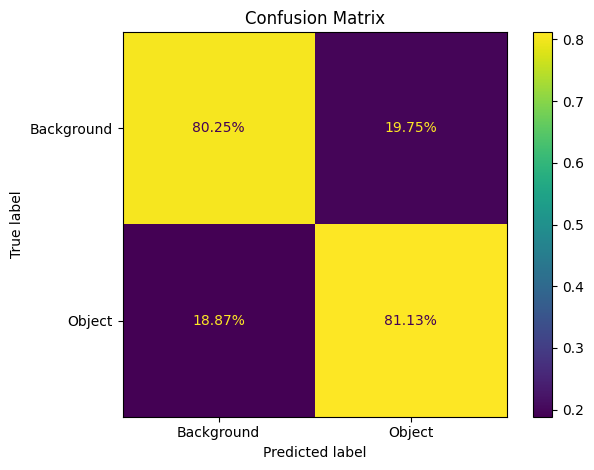

Dice: 0.09487408047684648
Precision: 0.05038275979133495
Recall: 0.8113498113498113

Training: Without Canny


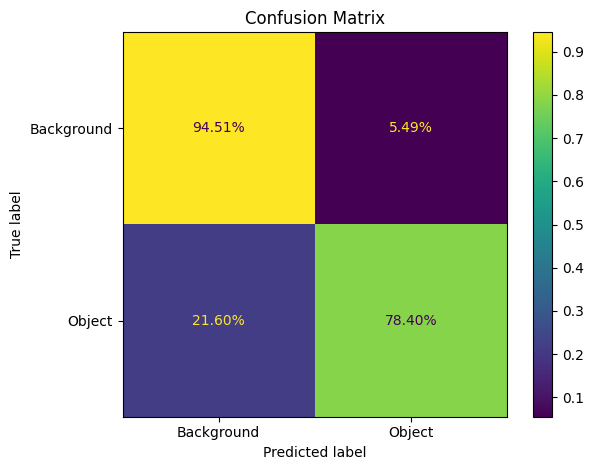

Dice: 0.2598509595753369
Precision: 0.15573331701870574
Recall: 0.784014784014784

Training: Only gradients


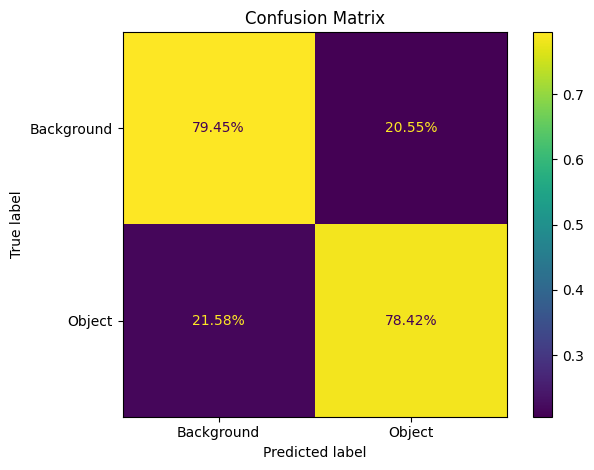

Dice: 0.08862802768918843
Precision: 0.04696795019598801
Recall: 0.7842457842457843

Training: Only grey + gradients


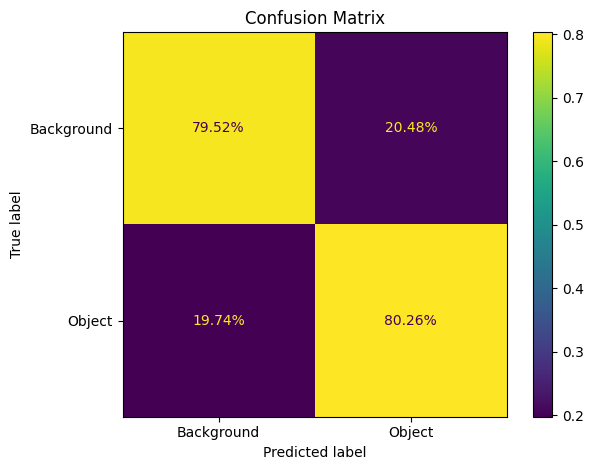

Dice: 0.09089997427523752
Precision: 0.0481780702889575
Recall: 0.8026488026488027



In [34]:
ablation_results = {}

for name, indices in feature_sets.items():
    print(f"Training: {name}")

    X_train_subset = select_features(X_train, indices)

    clf_subset = train_rf(
        X_train_subset,
        y_train,
        n_trees=100,
        random_state=0
    )

    y_pred_subset = [
        predict_segmentation_rf_selected(clf_subset, image, indices)
        for image in I_test
    ]

    results_subset = evaluate_binary_segmentation(y_pred_subset, y_test)

    ablation_results[name] = {
        "dice": results_subset["dice"],
        "precision": results_subset["precision"],
        "recall": results_subset["recall"]
    }

    print("Dice:", results_subset["dice"])
    print("Precision:", results_subset["precision"])
    print("Recall:", results_subset["recall"])
    print()


In [35]:
for name, scores in ablation_results.items():
    print(name)
    print("  Dice:     ", round(scores["dice"], 3))
    print("  Precision:", round(scores["precision"], 3))
    print("  Recall:   ", round(scores["recall"], 3))
    print()


All features
  Dice:      0.258
  Precision: 0.154
  Recall:    0.794

Without coordinates
  Dice:      0.095
  Precision: 0.05
  Recall:    0.811

Without Canny
  Dice:      0.26
  Precision: 0.156
  Recall:    0.784

Only gradients
  Dice:      0.089
  Precision: 0.047
  Recall:    0.784

Only grey + gradients
  Dice:      0.091
  Precision: 0.048
  Recall:    0.803



### 3.3. U-Net
In this task you will compare your results from the Random Forest segmentation to those from a U-Net. You will train two networks – one with data augmentation and one without. Feel free to tweak any hyperparameters if needed.
Then, you will evaluate the results and compare them to the Random Forest.

(Network details: the given convolutional neural network (CNN) is a U-Net ([paper](https://arxiv.org/pdf/1505.04597)) combined with a ResNet-34 backbone ([paper](https://arxiv.org/pdf/1512.03385)). It is lightweight and should be able to run about 100 epochs in less than 10 minutes even when only using a CPU. Unlike a regular ResNet, the residual connections are made on upsampling, where regular U-Nets would have concatenations. The `train_unet_model` function takes in all images and masks and splits them 30-10-10 into training, validation and testing. The model with the smallest validation loss will be returned. Note that every time the model has a new "best model", it saves the checkpoint in the `checkpoints` directory. These checkpoints are not deleted automatically and may start to take up considerable storage space when training multiple times.)

#### (a) Train two networks
 Train the networks `y_pred_UNet1` and `y_pred_UNet2`. The code is already given and when run, `train_unet_model` will plot training and validation loss after training. 

If you want, you can tweak the learning rate and the number of epochs for training using the parameters `lr` and `n_epochs`. Should you have troubles with a cuda device or mps, simply use the `device_override` parameter to use a different device, e.g. `device_override='cpu'`.

In [36]:
# torchvision is installed through setup/environment.yml in the boneseg-env environment.


In [37]:
# albumentations and tqdm is installed through setup/environment.yml in the boneseg-env environment.


In [38]:
# typing_extensions is installed through setup/environment.yml in the boneseg-env environment.


In [39]:
import sys
print(sys.executable)


/opt/homebrew/Caskroom/miniconda/base/envs/boneseg-env/bin/python


In [40]:
from training import train_unet_model


Using device: mps
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /Users/iana/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


  0%|          | 0.00/83.3M [00:00<?, ?B/s]

  1%|          | 1.00M/83.3M [00:00<00:08, 9.70MB/s]

  3%|▎         | 2.38M/83.3M [00:00<00:07, 12.0MB/s]

  5%|▍         | 3.88M/83.3M [00:00<00:06, 13.7MB/s]

...

Training Progress:  98%|█████████▊| 98/100 [02:00<00:01,  1.16epoch/s, train_loss=0.0896, val_loss=0.426]

Training Progress:  99%|█████████▉| 99/100 [02:00<00:00,  1.17epoch/s, train_loss=0.0896, val_loss=0.426]

Training Progress:  99%|█████████▉| 99/100 [02:01<00:00,  1.17epoch/s, train_loss=0.0855, val_loss=0.431]

Training Progress: 100%|██████████| 100/100 [02:01<00:00,  1.19epoch/s, train_loss=0.0855, val_loss=0.431]

Training Progress: 100%|██████████| 100/100 [02:01<00:00,  1.22s/epoch, train_loss=0.0855, val_loss=0.431]

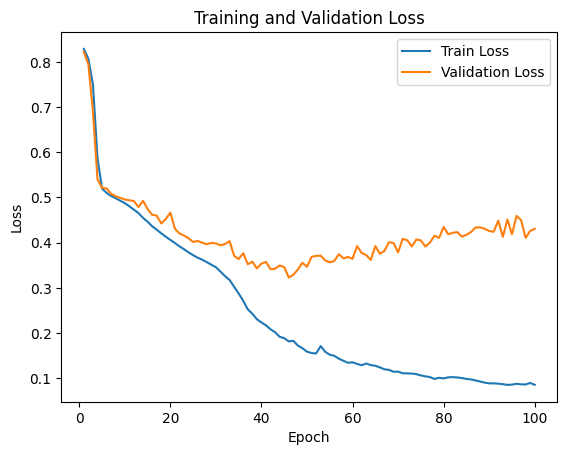

Best checkpoint was: checkpoints/best_epoch45_valloss0.3228.pth with val_loss=0.3228. Loading checkpoint...


Test Loss: 0.3249


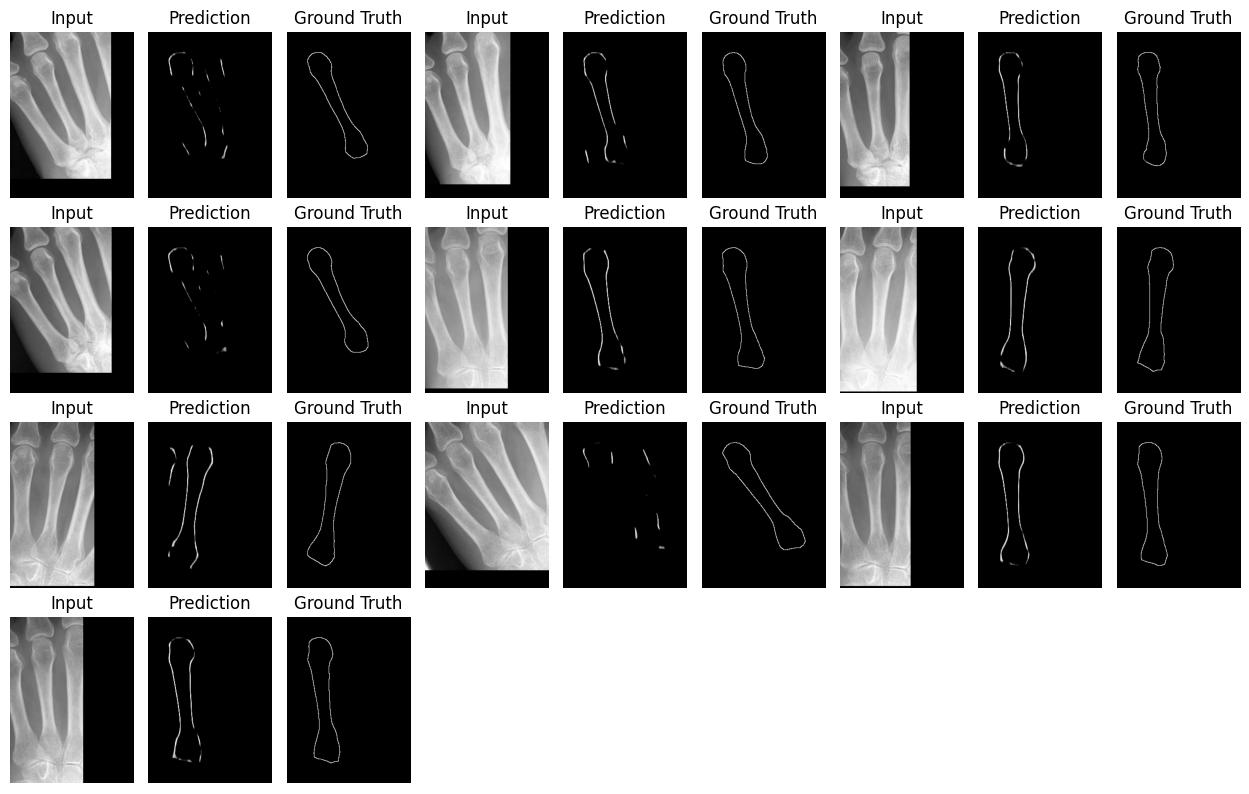

In [41]:
model_UNet1 = train_unet_model(images, masks, augment=False, lr=1e-4)


Using device: mps


Training Progress:   0%|          | 0/100 [00:00<?, ?epoch/s]

Training Progress:   0%|          | 0/100 [00:01<?, ?epoch/s, train_loss=0.86, val_loss=0.848]

Training Progress:   1%|          | 1/100 [00:01<02:20,  1.42s/epoch, train_loss=0.86, val_loss=0.848]

Training Progress:   1%|          | 1/100 [00:02<02:20,  1.42s/epoch, train_loss=0.841, val_loss=0.83]

...

Training Progress:  98%|█████████▊| 98/100 [02:10<00:02,  1.22s/epoch, train_loss=0.27, val_loss=0.31]  

Training Progress:  99%|█████████▉| 99/100 [02:10<00:01,  1.21s/epoch, train_loss=0.27, val_loss=0.31]

Training Progress:  99%|█████████▉| 99/100 [02:11<00:01,  1.21s/epoch, train_loss=0.27, val_loss=0.308]

Training Progress: 100%|██████████| 100/100 [02:11<00:00,  1.20s/epoch, train_loss=0.27, val_loss=0.308]

Training Progress: 100%|██████████| 100/100 [02:11<00:00,  1.31s/epoch, train_loss=0.27, val_loss=0.308]

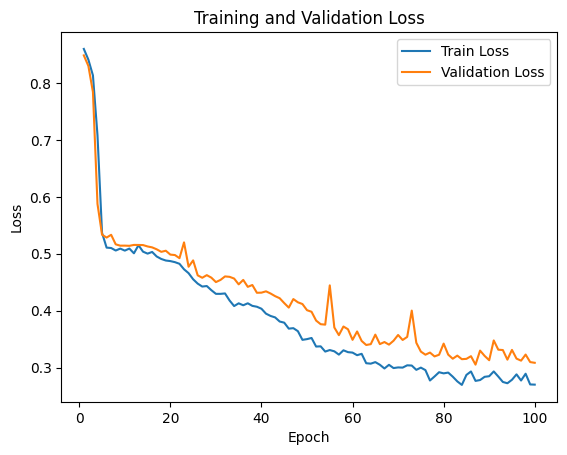

Best checkpoint was: checkpoints/best_epoch86_valloss0.3053.pth with val_loss=0.3053. Loading checkpoint...


Test Loss: 0.3082


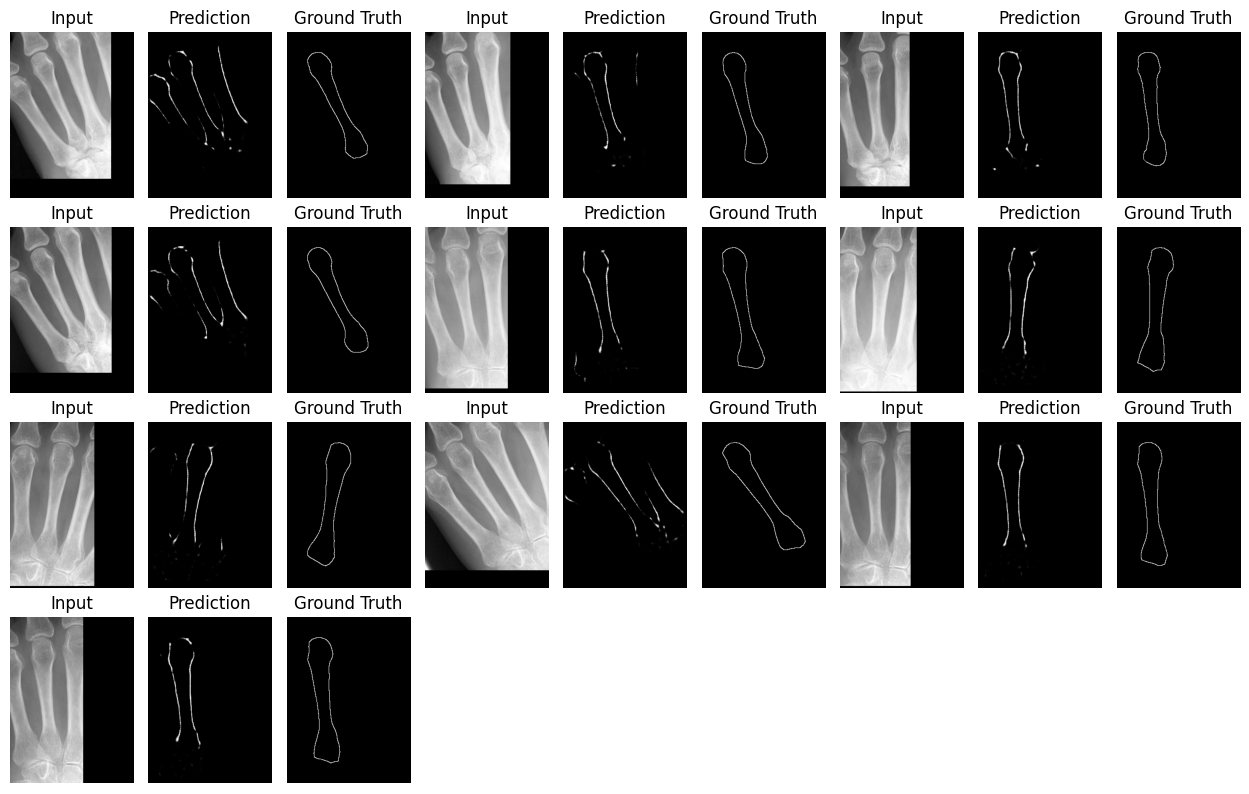

In [42]:
model_UNet2 = train_unet_model(images, masks, augment=True, lr=1e-4)


#### (b) Interpret filters
Instead of using a predefined set of filters (as we used in Task 2.1 for edge detection),  a convolutional neural network – learns the filter weights  during training to extract image features in combination with convolution. In this task we want to analyse and visualize which image features are extracted by the first layer of one of the trained U-Net classifiers. Therefore, use the trained U-Net model's method `show_first_layer_outputs` and a test image of your choice.

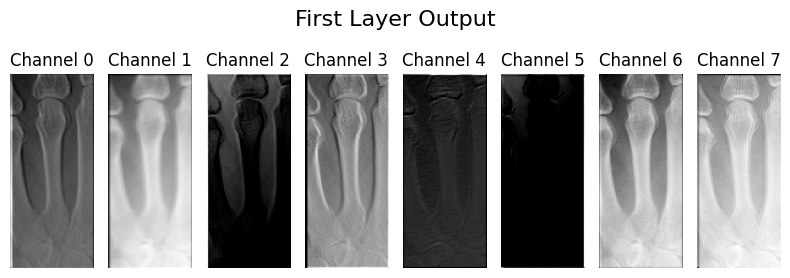

In [43]:
model_UNet2.show_first_layer_outputs(I_test[0])


#### (c) Predict contours
- Use the trained U-Net classifiers to predict the bone contours for the image test set `I_test` and store the predictions in `y_pred_UNet1` and `y_pred_UNet2`. Plot your predictions, the input and ground truth using `plot_prediction_triplets`.

In [44]:

y_pred_UNet1 = [model_UNet1.predict_segmentation(image) for image in I_test]
y_pred_UNet2 = [model_UNet2.predict_segmentation(image) for image in I_test]


In [45]:
print("Number of predictions without augmentation:", len(y_pred_UNet1))
print("Number of predictions with augmentation:", len(y_pred_UNet2))

print("First U-Net 1 prediction shape:", y_pred_UNet1[0].shape)
print("First U-Net 2 prediction shape:", y_pred_UNet2[0].shape)
print("Ground truth shape:", y_test[0].shape)

print("Unique values U-Net 1:", np.unique(y_pred_UNet1[0]))
print("Unique values U-Net 2:", np.unique(y_pred_UNet2[0]))


Number of predictions without augmentation: 20
Number of predictions with augmentation: 20
First U-Net 1 prediction shape: (322, 138)
First U-Net 2 prediction shape: (322, 138)
Ground truth shape: (322, 138)
Unique values U-Net 1: [0. 1.]
Unique values U-Net 2: [0. 1.]


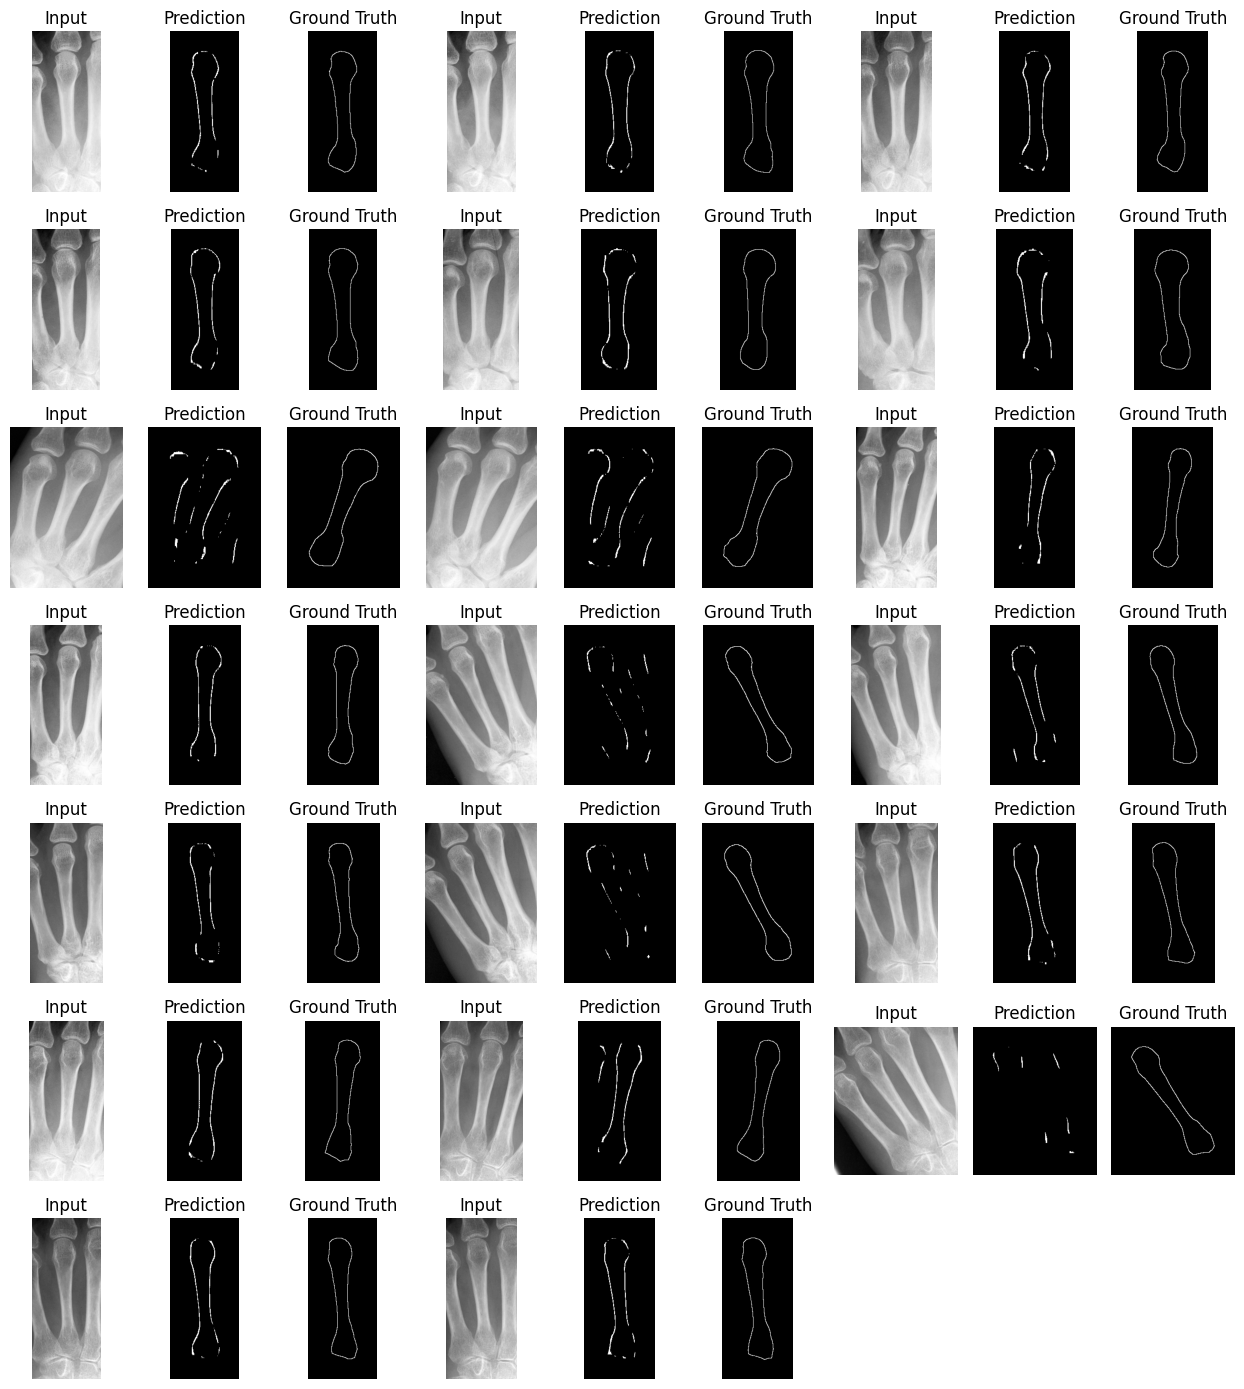

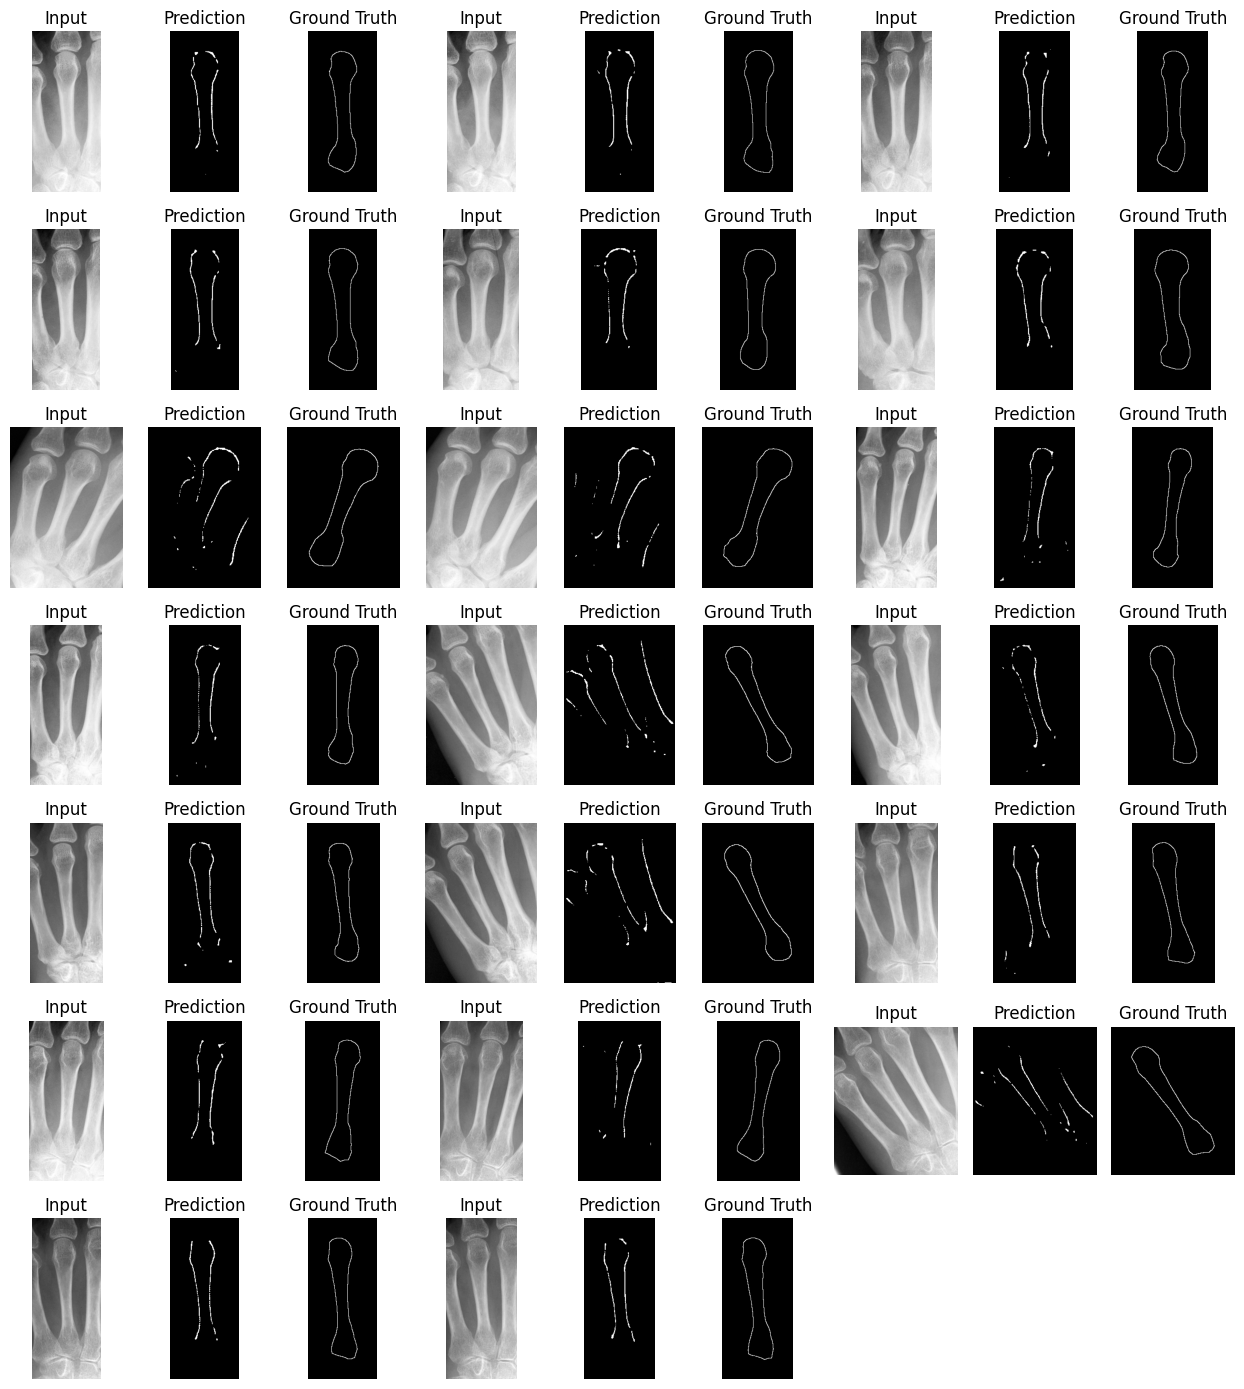

In [46]:

plot_prediction_triplets(I_test, y_pred_UNet1, y_test)
plot_prediction_triplets(I_test, y_pred_UNet2, y_test)


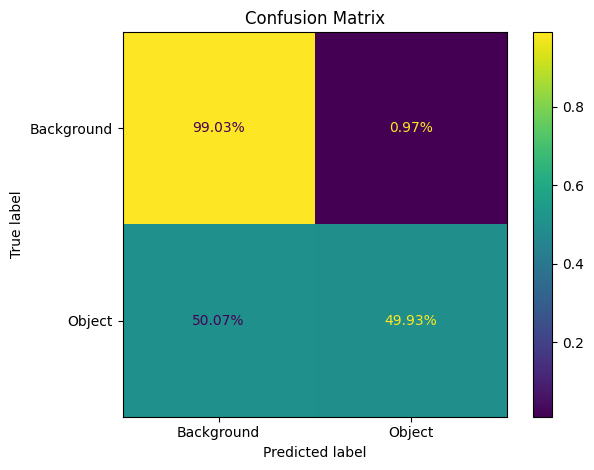

Dice Score: 0.4434413896867734
Precision: 0.3988435750753522
Recall: 0.49926849926849926


In [47]:
results_no_aug = evaluate_binary_segmentation(y_pred_UNet1, y_test)
print("Dice Score:", results_no_aug['dice'])
print("Precision:", results_no_aug['precision'])
print("Recall:", results_no_aug['recall'])


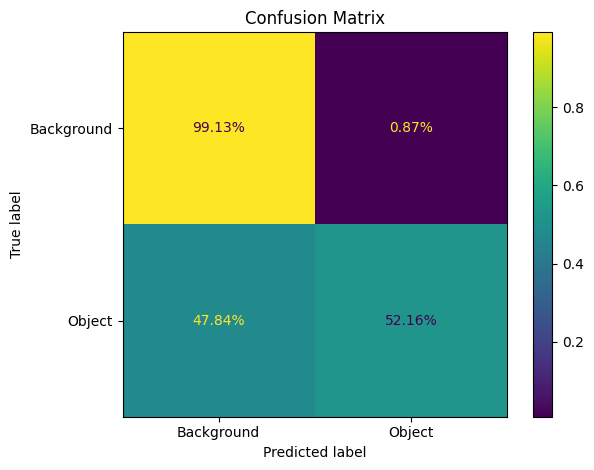

Dice Score: 0.4751016972927479
Precision: 0.43621611179084296
Recall: 0.5215985215985216


In [48]:
results_with_aug = evaluate_binary_segmentation(y_pred_UNet2, y_test)
print("Dice Score:", results_with_aug['dice'])
print("Precision:", results_with_aug['precision'])
print("Recall:", results_with_aug['recall'])


### 3.4. Shape Particle Filters (PF)
Shape particle filters are sequential Monte Carlo Methods used for solving a segmentation task. Therefore a shape model is required, which subsequently is fitted to the image to be segmented. For this task we will be using the PCA shape model of the first 30 images (created in Task 1.4 of this assignment) and create a fitting routine including the definition of a cost function used in the optimization process of the fitting. The shape model will be fitted to the output of the Random Forest segmentations.

#### (a) Implement `fit_shape_model` and `cost_function`
As the first step we formulate a function that models costs of fitting a shape to a target image. We are looking for a point in a parameter space (described by shape parameters, rotation, scaling, and translation) which describes an optimal fitted shape that segments the contours of a target object.
Implement the function `fit_shape_model` which should take a target image segmentation (in our case a predicted segmentation by the RF classifier in `y_pred_RF`) and the parameters _p_ of the shape model as input. The implemented function should fit the shape model to the  target segmentation.
- For running the optimization, use the helper function `optimize`, which takes a cost function (`cost_function`) and the upper and lower boundaries for the parameters to optimize.
- Implement the cost function which returns a scalar value that describes how well the (from _p_) generated shapes fits the classification result. (The better the shape fits the classification result, the lower the returned value). The cost function will be used by `fit_shape_model` in order to run the optimization for fitting the shape model to the segmentation.

Both `fit_shape_model` and `cost_function` will use `generate_shape` to generate shapes based on the shape parameters of the shape model and the transformation parameters used for scaling, rotation and translation.

In [49]:

from scipy.ndimage import distance_transform_edt as edt
from helper_functions import optimize

def shape_fit_cost(p, distance_map, eigen_vectors, mean_data):
    d = eigen_vectors.shape[1]
    b = p[:d]
    scale = p[d]
    rotation = p[d + 1]
    x_t = p[d + 2]
    y_t = p[d + 3]

    shape = generate_shape(b, eigen_vectors, mean_data, scale, rotation, x_t, y_t)
    n_points = shape.size // 2
    x = np.rint(shape[:n_points]).astype(int)
    y = np.rint(shape[n_points:]).astype(int)

    height, width = distance_map.shape
    inside = (x >= 0) & (x < width) & (y >= 0) & (y < height)
    if not np.any(inside):
        return 1e6

    contour_cost = distance_map[y[inside], x[inside]].mean()
    outside_penalty = 100.0 * (1.0 - inside.mean())
    return contour_cost + outside_penalty

def cost_function(p, classification, eigen_vectors, mean_data):
    """Return a low cost when the generated shape lies close to the contour mask."""
    segmentation = classification > 0
    if not np.any(segmentation):
        return np.inf

    distance_map = edt(~segmentation)
    return shape_fit_cost(p, distance_map, eigen_vectors, mean_data)


In [50]:

def fit_shape_model(segmentation, eigen_vectors, eigen_values, mean_shape):
    """Fit the PCA shape model to a binary segmentation mask."""
    d = eigen_vectors.shape[1]
    height, width = segmentation.shape

    stddevs = np.sqrt(np.maximum(eigen_values[:d], 1e-8))
    b_lower = -3.0 * stddevs
    b_upper = 3.0 * stddevs

    n_points = mean_shape.size // 2
    mean_points = np.column_stack([mean_shape[:n_points], mean_shape[n_points:]])
    mean_size = max(np.ptp(mean_points[:, 0]), np.ptp(mean_points[:, 1]), 1.0)

    y_positive, x_positive = np.nonzero(segmentation > 0)
    if len(x_positive) > 0:
        target_size = max(np.ptp(x_positive), np.ptp(y_positive), 1.0)
    else:
        target_size = max(width, height) / 2.0

    scale_center = target_size / mean_size
    scale_lower = max(0.1, 0.4 * scale_center)
    scale_upper = min(5.0, 2.5 * scale_center)

    min_ = np.concatenate([b_lower, [scale_lower, -180.0, -width, -height]])
    max_ = np.concatenate([b_upper, [scale_upper,  180.0, 2.0 * width, 2.0 * height]])
    assert min_.shape == max_.shape == (d + 4,)

    segmentation = segmentation > 0
    if not np.any(segmentation):
        raise ValueError("Cannot fit a shape model to an empty segmentation.")

    distance_map = edt(~segmentation)

    def unified_cost_fn(p):
        return shape_fit_cost(p, distance_map, eigen_vectors, mean_shape)

    best_params = optimize(
        unified_cost_fn,
        min_,
        max_,
        n=120,
        max_iter=3000,
        min_iterations=100,
        random_state=0,
    )

    b_opt = best_params[:d]
    scale_opt = best_params[d]
    rot_opt = best_params[d + 1]
    x_t_opt = best_params[d + 2]
    y_t_opt = best_params[d + 3]

    fitted_shape = generate_shape(
        b_opt,
        eigen_vectors,
        mean_shape,
        scale_opt,
        rot_opt,
        x_t_opt,
        y_t_opt,
    )

    return fitted_shape, best_params


#### (b) Optimize for all test segmentations
- Optimize this function for all segmentations in `y_pred_RF` (20). We are using a stochastic optimization approach called Differential Evolution for this purpose.
- This method is very simple, robust and converges fast. We provide an implementation of this approach in optimize. An example to create and use a cost function for an optimization process can be found in `optimize_demo.py`. You can simply run it to get an example demonstration of the optimization.
- Visualize your results using the helper function plot_fitted_shapes. You may also plot the ground truth landmarks using this function.

In [51]:
from helper_functions import plot_fitted_shapes


In [52]:

fitted_results = [
    fit_shape_model(segmentation, eigen_vectors, eigen_values, mean_shape)
    for segmentation in y_pred_RF
]

fitted_shapes = [shape for shape, params in fitted_results]
fitted_params = [params for shape, params in fitted_results]


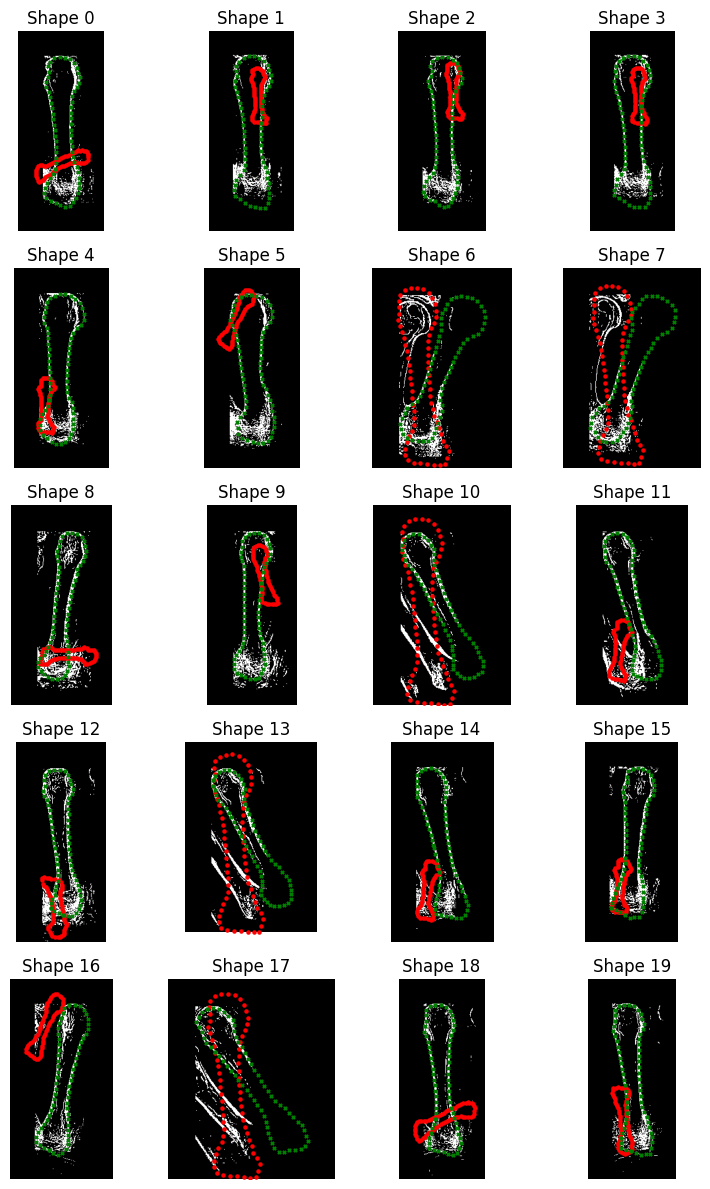

In [53]:
plot_fitted_shapes(fitted_shapes, y_pred_RF, gt_landmarks=landmarks[30:])
